# 06 - Predictions
Load the trained model and predict podium finishes for any race scenario.
- Load saved best model
- Predict single driver scenarios
- Predict full race grid (all 20 drivers)
- Visualise podium probabilities

In [1]:
import pandas as pd
import numpy as np
import pickle
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
with open('../models/best_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('../models/feature_columns.json', 'r') as f:
    feature_columns = json.load(f)

print("Model loaded! ✅")
print("Model type:", type(model).__name__)
print("\nExpected features:", feature_columns)

Model loaded! ✅
Model type: RandomForestClassifier

Expected features: ['GridPosition', 'GridPosition_Squared', 'Grid_vs_Avg', 'TeamID', 'IsTopTeam', 'Driver_Top3_SoFar', 'Driver_AvgPos_Last3', 'Driver_FinishRate', 'Team_Top3_SoFar', 'Team_AvgPos']


# Single driver prediction — Verstappen from P1

In [3]:
scenario = pd.DataFrame([{
    'GridPosition': 1,
    'GridPosition_Squared': 1,
    'Grid_vs_Avg': -9.5,
    'TeamID': 0,
    'IsTopTeam': 1,
    'Driver_Top3_SoFar': 15,
    'Driver_AvgPos_Last3': 1.3,
    'Driver_FinishRate': 0.95,
    'Team_Top3_SoFar': 30,
    'Team_AvgPos': 1.5
}])

scenario = scenario[model.feature_names_in_]

pred = model.predict(scenario)[0]
prob = model.predict_proba(scenario)[0][1]

print("Scenario: Verstappen from P1 (Red Bull)")
print(f"Top 3 Prediction: {'YES ✅' if pred == 1 else 'NO ❌'}")
print(f"Podium Probability: {prob:.1%}")

Scenario: Verstappen from P1 (Red Bull)
Top 3 Prediction: YES ✅
Podium Probability: 94.0%


# Single driver prediction — Backmarker from P20

In [4]:
scenario2 = pd.DataFrame([{
    'GridPosition': 20,
    'GridPosition_Squared': 400,
    'Grid_vs_Avg': 9.5,
    'TeamID': 8,
    'IsTopTeam': 0,
    'Driver_Top3_SoFar': 0,
    'Driver_AvgPos_Last3': 18.5,
    'Driver_FinishRate': 0.5,
    'Team_Top3_SoFar': 0,
    'Team_AvgPos': 17.0
}])

scenario2 = scenario2[model.feature_names_in_]

pred2 = model.predict(scenario2)[0]
prob2 = model.predict_proba(scenario2)[0][1]

print("Scenario: Backmarker from P20")
print(f"Top 3 Prediction: {'YES ✅' if pred2 == 1 else 'NO ❌'}")
print(f"Podium Probability: {prob2:.1%}")

Scenario: Backmarker from P20
Top 3 Prediction: NO ❌
Podium Probability: 0.0%


# Full race grid prediction — all 20 drivers

In [5]:
grid = pd.DataFrame([
    {'Driver': 'Max Verstappen',    'GridPosition': 1,  'TeamID': 0, 'IsTopTeam': 1, 'Driver_Top3_SoFar': 15, 'Driver_AvgPos_Last3': 1.3,  'Driver_FinishRate': 0.95, 'Team_Top3_SoFar': 30, 'Team_AvgPos': 1.5},
    {'Driver': 'Sergio Perez',      'GridPosition': 2,  'TeamID': 0, 'IsTopTeam': 1, 'Driver_Top3_SoFar': 8,  'Driver_AvgPos_Last3': 3.0,  'Driver_FinishRate': 0.85, 'Team_Top3_SoFar': 30, 'Team_AvgPos': 1.5},
    {'Driver': 'Lewis Hamilton',    'GridPosition': 3,  'TeamID': 3, 'IsTopTeam': 1, 'Driver_Top3_SoFar': 5,  'Driver_AvgPos_Last3': 4.5,  'Driver_FinishRate': 0.90, 'Team_Top3_SoFar': 10, 'Team_AvgPos': 4.0},
    {'Driver': 'Carlos Sainz',      'GridPosition': 4,  'TeamID': 2, 'IsTopTeam': 1, 'Driver_Top3_SoFar': 4,  'Driver_AvgPos_Last3': 5.0,  'Driver_FinishRate': 0.88, 'Team_Top3_SoFar': 8,  'Team_AvgPos': 4.5},
    {'Driver': 'Charles Leclerc',   'GridPosition': 5,  'TeamID': 2, 'IsTopTeam': 1, 'Driver_Top3_SoFar': 3,  'Driver_AvgPos_Last3': 6.0,  'Driver_FinishRate': 0.80, 'Team_Top3_SoFar': 8,  'Team_AvgPos': 4.5},
    {'Driver': 'Fernando Alonso',   'GridPosition': 6,  'TeamID': 1, 'IsTopTeam': 1, 'Driver_Top3_SoFar': 6,  'Driver_AvgPos_Last3': 4.0,  'Driver_FinishRate': 0.90, 'Team_Top3_SoFar': 12, 'Team_AvgPos': 3.5},
    {'Driver': 'George Russell',    'GridPosition': 7,  'TeamID': 3, 'IsTopTeam': 1, 'Driver_Top3_SoFar': 2,  'Driver_AvgPos_Last3': 6.5,  'Driver_FinishRate': 0.88, 'Team_Top3_SoFar': 10, 'Team_AvgPos': 4.0},
    {'Driver': 'Lando Norris',      'GridPosition': 8,  'TeamID': 4, 'IsTopTeam': 0, 'Driver_Top3_SoFar': 1,  'Driver_AvgPos_Last3': 7.0,  'Driver_FinishRate': 0.85, 'Team_Top3_SoFar': 3,  'Team_AvgPos': 7.0},
    {'Driver': 'Lance Stroll',      'GridPosition': 9,  'TeamID': 1, 'IsTopTeam': 1, 'Driver_Top3_SoFar': 1,  'Driver_AvgPos_Last3': 9.0,  'Driver_FinishRate': 0.80, 'Team_Top3_SoFar': 12, 'Team_AvgPos': 3.5},
    {'Driver': 'Oscar Piastri',     'GridPosition': 10, 'TeamID': 4, 'IsTopTeam': 0, 'Driver_Top3_SoFar': 0,  'Driver_AvgPos_Last3': 9.5,  'Driver_FinishRate': 0.82, 'Team_Top3_SoFar': 3,  'Team_AvgPos': 7.0},
    {'Driver': 'Esteban Ocon',      'GridPosition': 11, 'TeamID': 5, 'IsTopTeam': 0, 'Driver_Top3_SoFar': 0,  'Driver_AvgPos_Last3': 11.0, 'Driver_FinishRate': 0.78, 'Team_Top3_SoFar': 0,  'Team_AvgPos': 10.0},
    {'Driver': 'Pierre Gasly',      'GridPosition': 12, 'TeamID': 5, 'IsTopTeam': 0, 'Driver_Top3_SoFar': 0,  'Driver_AvgPos_Last3': 12.0, 'Driver_FinishRate': 0.78, 'Team_Top3_SoFar': 0,  'Team_AvgPos': 10.0},
    {'Driver': 'Valtteri Bottas',   'GridPosition': 13, 'TeamID': 6, 'IsTopTeam': 0, 'Driver_Top3_SoFar': 0,  'Driver_AvgPos_Last3': 13.0, 'Driver_FinishRate': 0.75, 'Team_Top3_SoFar': 0,  'Team_AvgPos': 12.0},
    {'Driver': 'Zhou Guanyu',       'GridPosition': 14, 'TeamID': 6, 'IsTopTeam': 0, 'Driver_Top3_SoFar': 0,  'Driver_AvgPos_Last3': 14.0, 'Driver_FinishRate': 0.72, 'Team_Top3_SoFar': 0,  'Team_AvgPos': 12.0},
    {'Driver': 'Yuki Tsunoda',      'GridPosition': 15, 'TeamID': 7, 'IsTopTeam': 0, 'Driver_Top3_SoFar': 0,  'Driver_AvgPos_Last3': 14.5, 'Driver_FinishRate': 0.70, 'Team_Top3_SoFar': 0,  'Team_AvgPos': 13.0},
    {'Driver': 'Kevin Magnussen',   'GridPosition': 16, 'TeamID': 8, 'IsTopTeam': 0, 'Driver_Top3_SoFar': 0,  'Driver_AvgPos_Last3': 15.0, 'Driver_FinishRate': 0.68, 'Team_Top3_SoFar': 0,  'Team_AvgPos': 14.0},
    {'Driver': 'Nico Hulkenberg',   'GridPosition': 17, 'TeamID': 8, 'IsTopTeam': 0, 'Driver_Top3_SoFar': 0,  'Driver_AvgPos_Last3': 15.5, 'Driver_FinishRate': 0.68, 'Team_Top3_SoFar': 0,  'Team_AvgPos': 14.0},
    {'Driver': 'Alexander Albon',   'GridPosition': 18, 'TeamID': 9, 'IsTopTeam': 0, 'Driver_Top3_SoFar': 0,  'Driver_AvgPos_Last3': 16.0, 'Driver_FinishRate': 0.65, 'Team_Top3_SoFar': 0,  'Team_AvgPos': 15.0},
    {'Driver': 'Logan Sargeant',    'GridPosition': 19, 'TeamID': 9, 'IsTopTeam': 0, 'Driver_Top3_SoFar': 0,  'Driver_AvgPos_Last3': 17.0, 'Driver_FinishRate': 0.60, 'Team_Top3_SoFar': 0,  'Team_AvgPos': 15.0},
    {'Driver': 'Nyck de Vries',     'GridPosition': 20, 'TeamID': 7, 'IsTopTeam': 0, 'Driver_Top3_SoFar': 0,  'Driver_AvgPos_Last3': 18.0, 'Driver_FinishRate': 0.55, 'Team_Top3_SoFar': 0,  'Team_AvgPos': 13.0},
])

print("Race grid built!")
print("Drivers:", grid.shape[0])

Race grid built!
Drivers: 20


In [6]:
drivers = grid['Driver'].values
X_grid = grid.drop(columns=['Driver'])

# Add missing engineered columns
X_grid['GridPosition_Squared'] = X_grid['GridPosition'] ** 2
X_grid['Grid_vs_Avg'] = X_grid['GridPosition'] - X_grid['GridPosition'].mean()

# Reorder to match model
X_grid = X_grid[model.feature_names_in_]

probs = model.predict_proba(X_grid)[:, 1]
preds = model.predict(X_grid)

results = pd.DataFrame({
    'Driver': drivers,
    'GridPosition': grid['GridPosition'].values,
    'PodiumProbability': probs,
    'Prediction': ['YES ✅' if p == 1 else 'NO ❌' for p in preds]
}).sort_values('PodiumProbability', ascending=False)

print("Full race grid predictions:")
print(results.to_string(index=False))

Full race grid predictions:
         Driver  GridPosition  PodiumProbability Prediction
 Max Verstappen             1           0.940000      YES ✅
   Sergio Perez             2           0.840000      YES ✅
Fernando Alonso             6           0.699442      YES ✅
 Lewis Hamilton             3           0.470963       NO ❌
   Carlos Sainz             4           0.459851       NO ❌
Charles Leclerc             5           0.309442       NO ❌
   Lance Stroll             9           0.280000       NO ❌
 George Russell             7           0.228494       NO ❌
Valtteri Bottas            13           0.020000       NO ❌
   Lando Norris             8           0.010000       NO ❌
  Oscar Piastri            10           0.010000       NO ❌
   Esteban Ocon            11           0.000000       NO ❌
   Pierre Gasly            12           0.000000       NO ❌
    Zhou Guanyu            14           0.000000       NO ❌
   Yuki Tsunoda            15           0.000000       NO ❌
Kevin Magnus

# Visualise podium probabilities

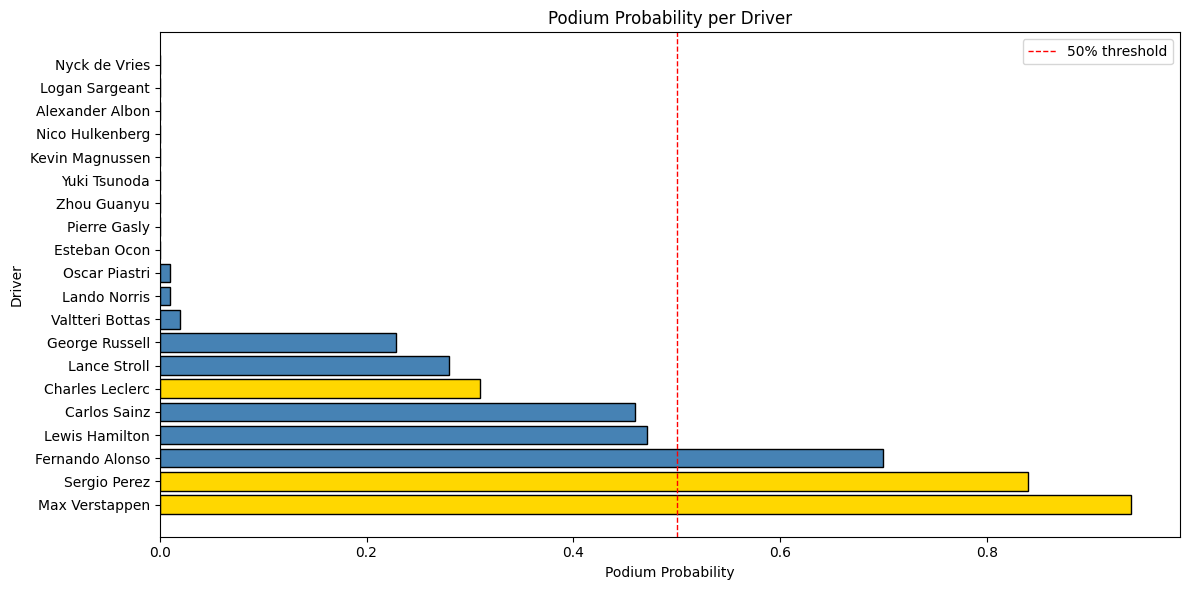

Chart saved!


In [7]:
os.makedirs('../charts', exist_ok=True)

plt.figure(figsize=(12, 6))
colors = ['gold' if p == 1 else 'steelblue' for p in preds]
plt.barh(results['Driver'], results['PodiumProbability'], color=colors, edgecolor='black')
plt.axvline(0.5, color='red', linestyle='--', linewidth=1, label='50% threshold')
plt.title('Podium Probability per Driver')
plt.xlabel('Podium Probability')
plt.ylabel('Driver')
plt.legend()
plt.tight_layout()
plt.savefig('../charts/podium_probabilities.png', dpi=150)
plt.show()
print("Chart saved!")

# Predicted podium top 3

In [8]:
top3 = results.head(3).reset_index(drop=True)
print("=============================")
print("     PREDICTED PODIUM")
print("=============================")
for i, row in top3.iterrows():
    medal = ['🥇', '🥈', '🥉'][i]
    print(f"{medal} P{i+1}: {row['Driver']} — {row['PodiumProbability']:.1%}")
print("=============================")

     PREDICTED PODIUM
🥇 P1: Max Verstappen — 94.0%
🥈 P2: Sergio Perez — 84.0%
🥉 P3: Fernando Alonso — 69.9%
